### 1. Loading the data set

In [154]:
%reset -f

import numpy as np
from scipy.io import loadmat

# Load the MATLAB file
data = loadmat('case2_trainingset_randomCurrent_v4_5mS')

# Extract the variables
V1 = data['V1']  # The 'V1' is the variable name in the .mat file
V2 = data['V2']  # The 'V2' is the variable name in the .mat file
random_I = data['random_I']  # The random_I is the variable name in the .mat file
random_P = data['random_P']  # The random_P is the variable name in the .mat file


### 2. Plotting the data set

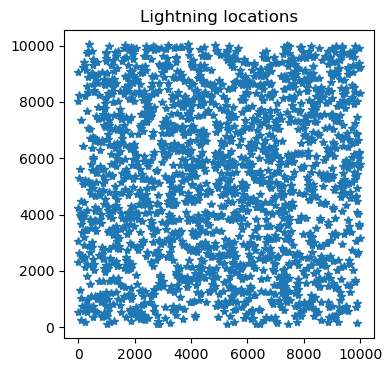

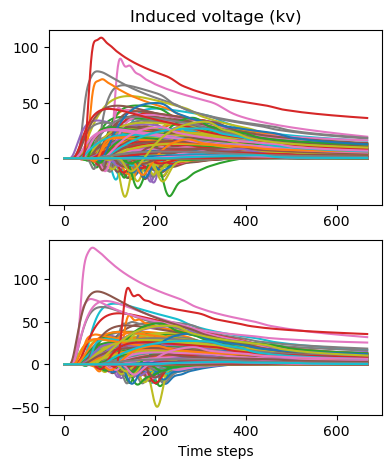

In [155]:
import numpy as np
import matplotlib.pyplot as plt

# Plotting the points from random_P
plt.figure(1,figsize=(4, 4))
plt.plot(random_P[:, 0], random_P[:, 1], '*')
plt.title('Lightning locations', fontsize=12)

# Plotting V1 and V2 in a 2-row subplot structure
plt.figure(2,figsize=(4.3, 5))
plt.subplot(2, 1, 1)  # 2 rows, 1 column, 1st subplot
plt.title('Induced voltage (kv)', fontsize=12)
plt.plot(V1)

plt.subplot(2, 1, 2)  # 2 rows, 1 column, 2nd subplot
plt.plot(V2)
plt.xlabel('Time steps')

plt.show()

### 3. Excluding abnormal curves ( Outlier Exclusion Procedure )

In [156]:
# Steady Voltage Range: Defines minimum and maximum steady voltage values.
V_min_steady = -5
V_max_steady = 40

# Filtering Data: Identifies cases where both V1 and V2 are within the specified steady voltage range.
good_cases = (V1[-1,:] > V_min_steady) & (V1[-1,:] < V_max_steady) & \
             (V2[-1,:] > V_min_steady) & (V2[-1,:] < V_max_steady)
nonZeroCount = np.count_nonzero(good_cases)

if nonZeroCount == V1.shape[1]:
    print('The entire dataset is good.')
else:
    print(f'Number of good cases: {nonZeroCount}')


The entire dataset is good.


### 4. Leading zeros removal and trauncation

In [157]:
# Combine Voltage Data: Creates a matrix V by concatenating the selected columns of V1 and V2.
V = np.concatenate((V1[:,good_cases], V2[:,good_cases]), axis=1)

# Transpose the matrix V to ensure observations are represented as rows and features as columns.
V = V.T

# Threshold Value: Defines a threshold value.
threshold = 1e-4

# Find Rows and Columns: Finds the row and column indices where the absolute value of V exceeds the threshold.
rows, cols = np.where(abs(V) > threshold)

# print(f'Number of all data sets: {V.shape[0] * V.shape[1]}')
# print(f'Count of datasets above the threshold: {len(rows)}')
# print(f'Count of datasets under the threshold: {(V.shape[0] * V.shape[1]) - len(rows)}')

# Compute the differences between consecutive elements in the rows array and identify indexes with the same rows.
drows = np.diff(rows)

# Adds a value of 1 at the beginning of the drows array. 
# This ensures that the first element of drows corresponds to the first element of rows.
drows = np.insert(drows, 0, 1)

# Starting column for each row.
starting = cols[drows == 1]

# Splitting the starting array for the two halves.
half_size = V.shape[0] // 2
starting1 = starting[:half_size]
starting2 = starting[half_size:]

# Combining and finding the minimum starting column for synchronization.
starting = np.vstack((starting1, starting2))
starting = np.min(starting, axis=0)

# Duplicates the starting array. 
starting = np.concatenate((starting, starting), axis=0)

# Creating a synchronized V matrix, initially filled with zeros.
V_sync = np.zeros(V.shape)

# Synchronizing the rows based on the starting column.
for i in range(len(starting)):
    column_length = len(V[i, starting[i]:])
    V_sync[i,:column_length] = V[i, starting[i]:]

# Truncating the V_sync matrix
V_sync = V_sync[:, :-(max(starting))]

# Reshaping the V_sync matrix.
V_sync = np.concatenate((V_sync[:half_size,:], V_sync[half_size:,:]), axis=1)

# Getting dimensions.
N_obs, N_vars = V_sync.shape

print(f'N_obs: {N_obs}, N_vars: {N_vars}')

N_obs: 2000, N_vars: 618


#### Plotting the processed data

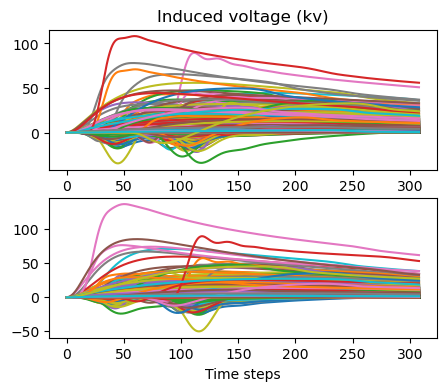

In [158]:
# Plotting V1 and V2 in a 2-row subplot structure
plt.figure(2,figsize=(5, 4))
plt.subplot(2, 1, 1)  # 2 rows, 1 column, 1st subplot
plt.title('Induced voltage (kv)', fontsize=12)
plt.plot(V_sync[:,:int(N_vars/2)].T)

plt.subplot(2, 1, 2)  # 2 rows, 1 column, 2nd subplot
plt.plot(V_sync[:,int(N_vars/2):].T)
plt.xlabel('Time steps')

plt.show()

### 5. Creating and splitting DataFrames

* #### Creating pandas DataFrames

In [159]:
import pandas as pd

# Create pandas DataFrames
X_columns1 = [f'x({i})' for i in range(1, int(V_sync.shape[1]/4) + 1)]
X_columns2 = [f'x({i})' for i in range(int(V_sync.shape[1]/4), 2*int(V_sync.shape[1]/4) + 1)]
X_columns3 = [f'x({i})' for i in range(2*int(V_sync.shape[1]/4), 3*int(V_sync.shape[1]/4) + 1)]
X_columns4 = [f'x({i})' for i in range(3*int(V_sync.shape[1]/4), V_sync.shape[1] + 1)]

X_columns  = [f'x({i})' for i in range(1, V_sync.shape[1] + 1)]

X = pd.DataFrame(V_sync, columns = X_columns)
# X_curr is a DataFrame containing V_sync data with column names x(1), x(2), ..., x(n)

Y = pd.DataFrame(random_I, columns=['Y'])
# Y is a DataFrame containing random_I data with a column named 'Y'

# Y is a DataFrame containing position data with a column named 'Y'
Y_p = pd.DataFrame(random_P, columns=['Y1','Y2'])

data_df = pd.concat([X, Y, Y_p], axis=1)
# Concatenate X_curr and Y DataFrames horizontally based on columns

data_df.head()
# Display the first few rows of the merged DataFrame

,x(1),x(2),x(3),x(4),x(5),x(6),x(7),x(8),x(9),x(10),...,x(612),x(613),x(614),x(615),x(616),x(617),x(618),Y,Y1,Y2
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,...,0.639981,0.639416,0.638869,0.638081,0.637338,0.636248,0.635232,21.368749,8491.293059,6881.887847
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,...,1.086368,1.080152,1.073716,1.065749,1.057419,1.047419,1.036920,61.941779,9339.932478,9671.137957
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,...,1.691661,1.688633,1.685494,1.682212,1.678898,1.675406,1.671586,24.810779,6787.351549,4429.731776
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,...,0.633533,0.605459,0.576615,0.548235,0.519987,0.492079,0.464248,52.183878,7577.401306,9453.366544
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-2.036072e-31,-1.033077e-28,...,15.573676,15.536130,15.498932,15.462034,15.425335,15.388695,15.352295,22.773537,7431.324681,108.343246


* #### Merging each neighboring columns

In [160]:
# Function to calculate the median of every n consecutive columns
def merge_cols_and_insert_median(df, n, X):
    result_df = pd.DataFrame()
    # Iterating through groups of neighboring columns
    for i in range(0, len(df.columns), n):
        # Extracting the current group of neighboring columns
        current_group = df.iloc[:, i:i+n]
        # Calculating the median for the current group
        median_values = current_group.mean(axis=1)
        # Creating a new DataFrame for the current group with a column named based on the group index
        new_col_name = f'{X}({i//n + 1})'
        current_result_df = pd.DataFrame({new_col_name: median_values})
        # Concatenating the current group's result DataFrame to the overall result DataFrame
        result_df = pd.concat([result_df, current_result_df], axis=1)
    return result_df

# Apply the function to the DataFrame
result_df1 = merge_cols_and_insert_median(data_df[X_columns1], 3, 'X11')
result_df2 = merge_cols_and_insert_median(data_df[X_columns2], 5, 'X12')
result_df3 = merge_cols_and_insert_median(data_df[X_columns3], 3, 'X21')
result_df4 = merge_cols_and_insert_median(data_df[X_columns4], 5, 'X22')

# Concatenate X_curr and Y DataFrames horizontally based on columns
data_df = pd.concat([result_df1, result_df2,result_df3,result_df4, Y, Y_p], axis=1)

# Display the first few rows of the merged DataFrame
data_df.head()

,X11(1),X11(2),X11(3),X11(4),X11(5),X11(6),X11(7),X11(8),X11(9),X11(10),...,X22(26),X22(27),X22(28),X22(29),X22(30),X22(31),X22(32),Y,Y1,Y2
0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-3.337089e-17,-1.929900e-11,-1.852618e-07,...,0.646666,0.645316,0.643594,0.642039,0.640890,0.638737,0.635740,21.368749,8491.293059,6881.887847
1,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.035751e-11,-5.973559e-07,-5.390338e-04,...,1.117343,1.117299,1.116159,1.111637,1.099301,1.072681,1.042169,61.941779,9339.932478,9671.137957
2,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-6.210279e-14,-2.723191e-07,-1.655679e-04,1.485704e-02,...,1.753869,1.740599,1.727037,1.713579,1.700086,1.685380,1.673496,24.810779,6787.351549,4429.731776
3,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,-1.176990e-06,4.615554e-03,3.600917e-02,1.128781e-01,2.233160e-01,...,1.003221,0.972221,0.916865,0.830903,0.714136,0.576766,0.478163,52.183878,7577.401306,9453.366544
4,0.0,0.0,-6.786907e-32,-3.744206e-26,-6.796821e-23,-2.377371e-20,-3.118451e-18,-2.068926e-16,-8.220832e-15,-2.178844e-13,...,16.498667,16.286590,16.080577,15.881044,15.687526,15.499221,15.370495,22.773537,7431.324681,108.343246


* #### Visualizing data with merged time steps

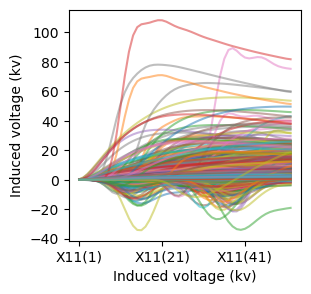

In [161]:
import matplotlib.pyplot as plt

# Plotting all columns with transparency
result_df1.T.plot(kind='line', legend=False, alpha=0.5, figsize=(3,3))

# Setting labels for the x and y axes
plt.xlabel('Induced voltage (kv)')
plt.ylabel('Induced voltage (kv)')

# Displaying the plot
plt.show()

* #### Splitting data

### 6. Pepare the Data for Machine Learning Algorithms

In [162]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(data_df.drop(columns=['Y']), data_df[['Y']], test_size=0.01, random_state=42)



* #### Feature scaling (Standardization (Z-score normalization))


In [163]:
# Import the StandardScaler from scikit-learn
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Standardize the training data
X_train = scaler.fit_transform(X_train)

# Use the same scaler to standardize the test and validation data
X_test = scaler.transform(X_test)
# X_valid = scaler.transform(X_valid)

### 7.  Initializing Neural Network Model and Configuring Parameters.

* #### Initializing Sequential Model with Hyperparameter Tuning and TensorBoard

In [164]:
import tensorflow as tf
from tensorflow import keras

# Clear Keras session to release resources and avoid conflicts with previous models
keras.backend.clear_session()

# Set random seeds for reproducibility
np.random.seed(42)  # Set seed for NumPy random functions
tf.random.set_seed(42)  # Set seed for TensorFlow random functions

# Import the os module for operating system-related functionalities
import os

# Define the root log directory using os.path.join to ensure cross-platform compatibility
root_logdir = os.path.join(os.curdir, "logs")

# Function to generate a unique run log directory based on the current timestamp
def get_run_logdir():
    import time
    # Generate a unique run identifier based on the current timestamp
    run_id = time.strftime("run_%Y_%m_%d-%H_%M_%S")  # Format: run_YYYY_MM_DD-HH_MM_SS
    return os.path.join(root_logdir, run_id)  # Construct the full path using os.path.join

# Get the run log directory using the defined function
run_logdir = get_run_logdir()

# Function to build a Keras model with configurable hyperparameters
def build_model(n_hidden=1, n_neurons=30, learning_rate=3e-3, input_shape=[X_train.shape[1:][0]]):
    model = keras.models.Sequential()
    model.add(keras.layers.InputLayer(input_shape=input_shape))
    
    # Add hidden layers with specified number of neurons and ReLU activation
    for layer in range(n_hidden):
        model.add(keras.layers.Dense(n_neurons, activation="sigmoid"))
    
    # Output layer for regression task
    model.add(keras.layers.Dense(1))
    
    # Compile the model with mean squared error loss and SGD optimizer
    optimizer = keras.optimizers.SGD(learning_rate=learning_rate)
    model.compile(loss="mse", optimizer=optimizer)
    
    return model

# Create a KerasRegressor using the build_model function
keras_reg = keras.wrappers.scikit_learn.KerasRegressor(build_model)

# Import necessary libraries
from scipy.stats import reciprocal
from sklearn.model_selection import RandomizedSearchCV

# Define parameter distributions for hyperparameter tuning
param_distribs = {
    "n_hidden": [3],  # Number of hidden layers
    "n_neurons": np.arange(74, 75).tolist(),  # Number of neurons per hidden layer
    "learning_rate": reciprocal(1.00e-3, 4e-3).rvs(1000).tolist(),  # Learning rate with reciprocal distribution
}

# Create a RandomizedSearchCV object
rnd_search_cv = RandomizedSearchCV(
    keras_reg,       # Keras model to be tuned
    param_distribs,  # Hyperparameter distributions
    n_iter=10,        # Number of parameter settings sampled
    cv=2,            # Number of cross-validation folds
    verbose=2,       # Verbosity level: 0 - silent, 1 - progress bar, 2 - one line per fit
    n_jobs=-1       # Use all available CPU cores
)

C:\Users\dodge\AppData\Local\Temp\ipykernel_5584\3712578298.py:46: DeprecationWarning: KerasRegressor is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  keras_reg = keras.wrappers.scikit_learn.KerasRegressor(build_model)


### 8.  Loading the model for x and y

In [165]:
# Import necessary libraries
from joblib import load
# Load the model
model_x = tf.keras.models.load_model('X_model')

### 9.  Compiling and training the model

* #### Training a Sequential Model with Manual CV

In [166]:
from sklearn.model_selection import KFold
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


# Initialize empty lists to store predictions and true values across all folds
all_y_pred = []
all_mse = []
all_mae = []
all_r2 = []
all_y_test = []

# Define your kfold
kfold = KFold(n_splits=10, shuffle=True, random_state=42)  # Assuming 5-fold cross-validation

for i, (train, test) in enumerate(kfold.split(X_train)):
    print('Training fold:', i)

    # I prediction
    x_trainFold, x_testFold = X_train[train], X_train[test]
    y_trainFold, y_testFold = y_train.iloc[train], y_train.iloc[test]
    
    rnd_search_cv.fit(
    x_trainFold, y_trainFold,  # Training data and labels
    epochs=1800,  # Number of training epochs
    # validation_data=(X_valid, y_valid),  # Validation data and labels
    callbacks=[keras.callbacks.EarlyStopping(monitor='loss',patience=1000,restore_best_weights=True)]  # Early stopping to prevent overfitting
    )
    # Get the best estimator/model from RandomizedSearchCV
    model = rnd_search_cv.best_estimator_
    

    # Make predictions on the test fold
    y_predFold = model.predict(x_testFold)

    # Evaluate the model on the test set using TensorFlow's evaluate method
    mse = mean_squared_error(y_testFold, y_predFold)
    # Calculate Mean Absolute Error (MAE)
    mae = mean_absolute_error(y_testFold, y_predFold)
    # Calculate R-squared for the test sets
    r2 = r2_score(y_testFold, y_predFold)
    
    # Append predictions, residuals, and true values to the respective lists
    all_y_pred.append(y_predFold)
    all_mse.append(mse)
    all_mae.append(mae)
    all_r2.append(r2)
    all_y_test.append(y_testFold)

# x coordinate prediction
# Make predictions on the test set using the trained model
y_pred = model.predict(X_test ) # 
# Evaluate the model on the test set using TensorFlow's evaluate method
mse = mean_squared_error(y_test, y_pred)
# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)
# Calculate R-squared for the test sets
r2 = r2_score(y_test, y_pred)

# Append predictions, residuals, and true values to the respective lists
all_y_pred.append(y_pred)
all_mse.append(mse)
all_mae.append(mae)
all_r2.append(r2)
all_y_test.append(y_test)

# Convert lists to numpy arrays if needed
all_y_pred = np.concatenate(all_y_pred)
all_y_test = np.concatenate(all_y_test)
all_mse = np.array(all_mse)
all_mae = np.array(all_mae)
all_r2 = np.array(all_r2)

Training fold: 0
Fitting 2 folds for each of 10 candidates, totalling 20 fits
Epoch 1/1800
56/56 [==============================] - 0s 1ms/step - loss: 393.4962
Epoch 2/1800
56/56 [==============================] - 0s 861us/step - loss: 280.4881
Epoch 3/1800
56/56 [==============================] - 0s 1ms/step - loss: 277.1742
Epoch 4/1800
56/56 [==============================] - 0s 773us/step - loss: 272.5136
Epoch 5/1800
56/56 [==============================] - 0s 1ms/step - loss: 266.9042
Epoch 6/1800
56/56 [==============================] - 0s 1ms/step - loss: 260.5858
Epoch 7/1800
56/56 [==============================] - 0s 860us/step - loss: 255.3690
Epoch 8/1800
56/56 [==============================] - 0s 852us/step - loss: 251.3882
Epoch 9/1800
56/56 [==============================] - 0s 1ms/step - loss: 246.6104
Epoch 10/1800
56/56 [==============================] - 0s 943us/step - loss: 239.9985
Epoch 11/1800
56/56 [==============================] - 0s 1ms/step - loss: 236.33

### 9.  Evaluateing the model

* #### Display the best model architecture

In [167]:
# # Get the best model from the search
model = rnd_search_cv.best_estimator_.model

# Display the model architecture
model.summary()

optimizer = model.optimizer

# Access learning rate
learning_rate = optimizer.learning_rate

# If the learning rate is a static value
print(f"Learning rate: {learning_rate.numpy():.2e}")

Model: "sequential_9"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_36 (Dense)            (None, 74)                12580     
                                                                 
 dense_37 (Dense)            (None, 74)                5550      
                                                                 
 dense_38 (Dense)            (None, 74)                5550      
                                                                 
 dense_39 (Dense)            (None, 1)                 75        
                                                                 
Total params: 23,755
Trainable params: 23,755
Non-trainable params: 0
_________________________________________________________________
Learning rate: 1.84e-03


* #### Plotting predictions against actual values and error

Test Set R-squared (x): 0.9791668379419375
Mean Squared Error (x): 6.1912767882501525
Mean Abs Error (x): 0.8026919588627082


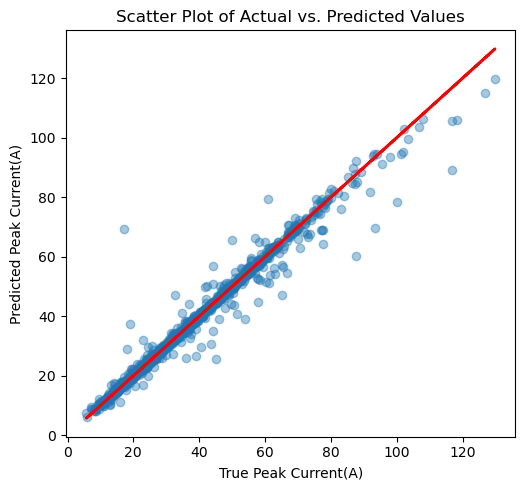

In [168]:
# Print R-squared for both training and validation sets
# R-squared tells you how much of the variation in y can be associated to the variation in x.
print("Test Set R-squared (x):", np.mean(all_r2))

# Print errors
print("Mean Squared Error (x):", np.mean(all_mse))

# Print errors
print("Mean Abs Error (x):", np.mean(all_mae))

# Set the figure size
plt.figure(figsize=(10, 5))

# Plotting some sample predictions against actual values
plt.subplot(1, 2, 1)
plt.scatter(all_y_test, all_y_pred, alpha=0.4, label='Actual vs. Predicted')
plt.plot(all_y_test,all_y_test, color='red', linewidth=2, label='Perfect Prediction Line')  # Add a line for perfect predictions
plt.xlabel('True Peak Current(A)')
plt.ylabel('Predicted Peak Current(A)')
plt.title('Scatter Plot of Actual vs. Predicted Values')

# Adjust layout
plt.tight_layout()

# Show the plots
plt.show()

* #### Converting to HTML

In [169]:
# !jupyter nbconvert --to html Lightning_Current.ipynb

* #### Saving the model

In [170]:
# Save the model
model.save(f'Current_model')

INFO:tensorflow:Assets written to: Current_model\assets


* #### Saving the predicted current

In [171]:
# # Generate predictions for the entire dataset using the trained model
# predicted_I = model.predict(data_df.drop(columns='Y'))

# Save predictions to a CSV file
np.savetxt('all_y_test_I.csv', all_y_test, delimiter=',')
np.savetxt('all_y_pred_I.csv', all_y_pred, delimiter=',')
np.savetxt('all_r2_I.csv', all_r2, delimiter=',')
np.savetxt('all_mse_I.csv', all_mse, delimiter=',')
np.savetxt('all_mae_I.csv', all_mae, delimiter=',')


* #### Visualize final results

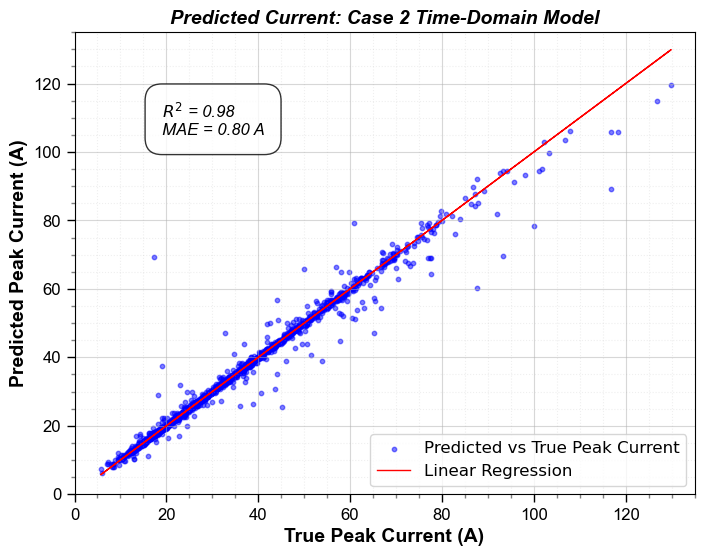

In [172]:

# Load CSV files back into numpy arrays
all_y_test = np.loadtxt('all_y_test_I.csv', delimiter=',')
all_y_pred = np.loadtxt('all_y_pred_I.csv', delimiter=',')
all_r2 = np.loadtxt('all_r2_I.csv', delimiter=',')
all_mse = np.loadtxt('all_mse_I.csv', delimiter=',')
all_mae = np.loadtxt('all_mae_I.csv', delimiter=',')

# Assuming y_total and y_pred are your data arrays

plt.figure(figsize=(8, 6))  # Set the figure size

# Scatter plot with smaller markers, customized colors, and transparency
plt.scatter(all_y_test, all_y_pred, alpha=0.5, label='Predicted vs True Peak Current', color='blue', marker='o', s=10)

# Line plot for perfect predictions with custom color and line style
plt.plot(all_y_test, all_y_test, color='red', linestyle='solid', linewidth=1, label='Linear Regression')

# Labels and legend with custom font size and style
plt.xlabel('True Peak Current (A)', fontsize=14, fontweight='bold', fontname='Arial')
plt.ylabel('Predicted Peak Current (A)', fontsize=14, fontweight='bold', fontname='Arial')
plt.legend(loc='lower right', fontsize=12)

# Set x and y limits
plt.xlim(0, 135)
plt.ylim(0, 135)

# Major and minor gridlines with custom linestyle and transparency
plt.grid(True, which='both', linestyle='-', alpha=0.5)
plt.grid(True, which='minor', linestyle=':', alpha=0.2)  # Set transparency for minor gridlines

# Customize ticks and tick labels
plt.xticks(fontsize=12, fontname='Arial')
plt.yticks(fontsize=12, fontname='Arial')

# Set minor ticks on both axes
plt.minorticks_on()

# Customize major and minor ticks
plt.tick_params(which='major', length=6, width=1)
plt.tick_params(which='minor', length=3, width=1, color='gray')

# Add a title
plt.title('Predicted Current: Case 2 Time-Domain Model',loc='center' , fontweight='bold', fontsize=14, fontname='Arial', fontstyle='italic')

# Add a text box with R^2 and MAE values
plt.text(19, 105, f'$R^2$ = {np.mean(all_r2):.2f}\nMAE = {np.mean(all_mae):.2f} A', fontsize=12, bbox=dict(facecolor='white', edgecolor='black', alpha=0.8, boxstyle='round,pad=1'), fontname='Arial', fontstyle='italic')

plt.show()